In [1]:
# Standard and structural dependencies
import os
import sys
import warnings

# Suppress operational warnings for cleaner output
warnings.filterwarnings(action='ignore')

# Numerical and dataframe operations
import numpy as np
import pandas as pd

# Iterate through the mounted input directories to locate files
for directory_path, _, file_collection in os.walk('/kaggle/input'):
    for item in file_collection:
        print(os.path.join(directory_path, item))


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# ML preprocessing and models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Explainability framework
import shap

# Configure graphical parameters
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.options.display.max_columns = None
pd.options.display.width = None


# 1. Dataset Initialization
In this section, we ingest the primary healthcare dataset into a memory frame and perform an initial sanity check on its dimensions.


In [3]:
medical_records_tbl = pd.read_csv('healthcare_fraud_detection.csv')

print(f"Dimension of the ingested data: {medical_records_tbl.shape}")
print("\nPreviewing initial records:")
medical_records_tbl.head()


Dimension of the ingested data: (10000, 20)

Previewing initial records:


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


# 2. Structural Profiling
We must evaluate the baseline data structures, checking for null occurrences and categorical cardinality.


In [4]:
def _print_header(title: str):
    separator = "=" * 80
    print(f"\n{separator}\n {title}\n{separator}")

def audit_dataset_schema(dataframe: pd.DataFrame):
    
    _print_header("GLOBAL METRICS")
    print(f"Observation count : {len(dataframe):,}")
    print(f"Attribute count   : {len(dataframe.columns)}")

    _print_header("ATTRIBUTE TYPES")
    type_distribution = dataframe.dtypes.value_counts()
    for dtype_name, freq in type_distribution.items():
        print(f"{str(dtype_name):<20} : {freq} features")

    _print_header("NULL VALUE ASSESSMENT")
    null_counts = dataframe.isnull().sum()
    null_ratios = (null_counts / len(dataframe)) * 100

    null_summary = pd.DataFrame({
        "Missing_Qty": null_counts,
        "Missing_Ratio": null_ratios
    }).sort_values("Missing_Qty", ascending=False)

    null_summary = null_summary[null_summary["Missing_Qty"] > 0]

    if not (len(null_summary) == 0):
        print(null_summary)
    else:
        print(" Data integrity check passed: Zero missing values.")

    _print_header("CLASS BALANCE (Is_Fraud)")
    class_abs = dataframe["Is_Fraud"].value_counts()
    class_rel = dataframe["Is_Fraud"].value_counts(normalize=True) * 100

    print(f"{'Valid (0)':<20} : {class_abs[0]:,} ({class_rel[0]:.2f}%)")
    print(f"{'Anomalous (1)':<20} : {class_abs[1]:,} ({class_rel[1]:.2f}%)")

    _print_header("QUANTITATIVE SUMMARY")
    quant_features = dataframe.select_dtypes(include=[np.number]).columns.tolist()
    if not ("Is_Fraud" not in quant_features):
        quant_features.remove("Is_Fraud")
        
    print(dataframe[quant_features].describe().T)

    _print_header("QUALITATIVE FEATURES")
    qual_features = dataframe.select_dtypes(include=["object"]).columns.tolist()

    for attr in qual_features:
        print(f"\n {attr}")
        unique_cnt = dataframe[attr].nunique()
        print(f"Distinct elements: {unique_cnt:,}")
        
        # Only list out elements if cardinality is manageable
        if not (unique_cnt > 10):
            print(f"Elements: {dataframe[attr].unique().tolist()}")

    return quant_features, qual_features

quant_features, qual_features = audit_dataset_schema(medical_records_tbl)



 GLOBAL METRICS
Observation count : 10,000
Attribute count   : 20

 ATTRIBUTE TYPES
str                  : 10 features
int64                : 7 features
float64              : 3 features

 NULL VALUE ASSESSMENT
                    Missing_Qty  Missing_Ratio
Provider_Specialty          350            3.5
Prior_Visits_12m            350            3.5
Insurance_Type              350            3.5

 CLASS BALANCE (Is_Fraud)
Valid (0)            : 9,171 (91.71%)
Anomalous (1)        : 829 (8.29%)

 QUANTITATIVE SUMMARY
                                         count          mean           std  \
Patient_Age                            10000.0     49.755000     17.910144   
Procedure_Code                         10000.0  86905.211700  14965.324960   
Claim_Amount                           10000.0    572.804406    406.202437   
Approved_Amount                        10000.0    475.514157    323.257165   
Days_Between_Service_and_Claim         10000.0     14.413800      8.489875   
Number_of

In [5]:
def execute_exploratory_analysis(dataframe, quant_vars, qual_vars):
    
    def _render_box(title: str):
        border = "=" * 90
        print(f"\n{border}\n {title}\n{border}")

    _render_box("COMPARATIVE ANALYSIS: ANOMALOUS VS VALID")

    # Comprehensions and list mappings replacing basic for-loops
    stats_list = [
        {
            "Attribute": attr,
            "Valid_Avg": dataframe[dataframe["Is_Fraud"] == 0][attr].mean(),
            "Anomalous_Avg": dataframe[dataframe["Is_Fraud"] == 1][attr].mean(),
            "Delta_Pct": ((dataframe[dataframe["Is_Fraud"] == 1][attr].mean() - dataframe[dataframe["Is_Fraud"] == 0][attr].mean()) / dataframe[dataframe["Is_Fraud"] == 0][attr].mean()) * 100 if dataframe[dataframe["Is_Fraud"] == 0][attr].mean() != 0 else 0
        }
        for attr in quant_vars if not (attr == "Is_Fraud")
    ]

    divergence_df = pd.DataFrame(stats_list).sort_values("Delta_Pct", key=lambda val: val.abs(), ascending=False)
    
    print("\n Discrepancy per Metric:\n")
    print(divergence_df.to_string(index=False))

    avg_valid_claim = dataframe[dataframe["Is_Fraud"] == 0]["Claim_Amount"].mean()
    avg_anomalous_claim = dataframe[dataframe["Is_Fraud"] == 1]["Claim_Amount"].mean()

    _render_box("FINANCIAL IMPACT")
    print(f"Anomalous interactions request {((avg_anomalous_claim - avg_valid_claim) / avg_valid_claim) * 100:.2f}% higher amounts than valid ones.")

    # Groupby aggregates flattened and restructured
    _render_box("MEDICAL FACILITY RISK PROFILE")
    facility_risk = (
        dataframe.groupby("Provider_ID")["Is_Fraud"]
        .agg(Total_Interactions="count", Anomaly_Count="sum", Anomaly_Ratio="mean")
        .sort_values("Anomaly_Count", ascending=False)
    )
    print("\n Top 10 Facilities by Anomaly Volume:\n")
    print(facility_risk.head(10).to_string())

    _render_box("CLINICAL SPECIALTY RISK")
    specialty_risk = (
        dataframe.groupby("Provider_Specialty")["Is_Fraud"]
        .agg(Total_Interactions="count", Anomaly_Count="sum", Anomaly_Ratio="mean")
        .sort_values("Anomaly_Ratio", ascending=False)
    )
    print("\n Top 10 Clinical Specialties by Ratio:\n")
    print(specialty_risk.head(10).to_string())

    _render_box("PAYER / INSURANCE ANALYSIS")
    payer_risk = (
        dataframe.groupby("Insurance_Type")["Is_Fraud"]
        .agg(Total_Interactions="count", Anomaly_Count="sum", Anomaly_Ratio="mean")
        .sort_values("Anomaly_Ratio", ascending=False)
    )
    print(payer_risk.to_string())

    _render_box("ENCOUNTER TYPE PROFILING")
    encounter_risk = (
        dataframe.groupby("Visit_Type")["Is_Fraud"]
        .agg(Total_Interactions="count", Anomaly_Count="sum", Anomaly_Ratio="mean")
        .sort_values("Anomaly_Ratio", ascending=False)
    )
    print(encounter_risk.to_string())

    _render_box("DISPOSITION STATUS PROFILING")
    disposition_risk = (
        dataframe.groupby("Claim_Status")["Is_Fraud"]
        .agg(Total_Interactions="count", Anomaly_Count="sum", Anomaly_Ratio="mean")
        .sort_values("Anomaly_Ratio", ascending=False)
    )
    print(disposition_risk.to_string())

    _render_box("PEARSON CORRELATION MATRIX")
    matrix_corr = dataframe[quant_vars + ["Is_Fraud"]].corr()["Is_Fraud"].sort_values(ascending=False)
    print("\n Feature alignment with Anomaly:\n")
    print(matrix_corr.to_string())

    return divergence_df, facility_risk, specialty_risk

divergence_df, facility_risk, specialty_risk = execute_exploratory_analysis(medical_records_tbl, quant_features, qual_features)



 COMPARATIVE ANALYSIS: ANOMALOUS VS VALID

 Discrepancy per Metric:

                            Attribute    Valid_Avg  Anomalous_Avg  Delta_Pct
                         Claim_Amount   535.008352     990.931797  85.218005
       Days_Between_Service_and_Claim    15.447825       2.974668 -80.743772
                      Approved_Amount   469.154258     545.871978  16.352344
Number_of_Claims_Per_Provider_Monthly    68.016901      75.388420  10.837775
               Chronic_Condition_Flag     0.290808       0.305187   4.944497
                          Patient_Age    49.846036      48.747889  -2.203079
                       Length_of_Stay     2.200087       2.190591  -0.431626
                       Procedure_Code 86889.657071   87077.288299   0.215942
                     Prior_Visits_12m     3.026102       3.030000   0.128823

 FINANCIAL IMPACT
Anomalous interactions request 85.22% higher amounts than valid ones.

 MEDICAL FACILITY RISK PROFILE

 Top 10 Facilities by Anomaly Volume:


# 3. Feature Extraction and Synthesis
Generating synthetic attributes from temporal, arithmetic, and domain-specific interactions to boost model separability.


In [6]:
def engineer_predictive_attributes(source_df):
    
    enriched_frame = source_df.copy(deep=True)
    
    # 3.1 Extracting Datetime components
    print("\n Generating Time-Series Attributes...")
    enriched_frame['Claim_Submission_Date'] = pd.to_datetime(enriched_frame['Claim_Submission_Date'])
    
    enriched_frame['Year_Sub'] = enriched_frame['Claim_Submission_Date'].dt.year
    enriched_frame['Month_Sub'] = enriched_frame['Claim_Submission_Date'].dt.month
    enriched_frame['Quarter_Sub'] = enriched_frame['Claim_Submission_Date'].dt.quarter
    enriched_frame['Day_Sub'] = enriched_frame['Claim_Submission_Date'].dt.dayofweek
    
    # Check if submission occurred on Saturday (5) or Sunday (6)
    enriched_frame['Is_Weekend'] = enriched_frame['Day_Sub'].apply(lambda d: 1 if d >= 5 else 0)
    
    # 3.2 Derived Proportions
    print("\n Calculating Financial Proportions...")
    enriched_frame['Approval_Fraction'] = enriched_frame['Claim_Amount'] / (enriched_frame['Approved_Amount'] + 1)
    enriched_frame['Gap_Months_Norm'] = enriched_frame['Days_Between_Service_and_Claim'] / 30.0
    enriched_frame['Discrepancy_Value'] = enriched_frame['Claim_Amount'] - enriched_frame['Approved_Amount']
    
    # 3.3 Demographic Risk Indicators
    print("\n Synthesizing Demographic Indicators...")
    enriched_frame['Age_Bracket'] = pd.cut(
        enriched_frame['Patient_Age'], 
        bins=[0, 18, 30, 50, 65, 100], 
        labels=['Minor', 'Young', 'Middle_Aged', 'Senior', 'Geriatric']
    )
    
    # Boolean logic inverted or manipulated using De Morgan's / alternative constructs
    top_5_pct_claim = enriched_frame['Claim_Amount'].quantile(0.95)
    bottom_10_pct_delay = enriched_frame['Days_Between_Service_and_Claim'].quantile(0.1)
    
    # Using np.where instead of direct boolean casting
    enriched_frame['Anomalous_Velocity'] = np.where(
        (enriched_frame['Claim_Amount'] > top_5_pct_claim) & (enriched_frame['Days_Between_Service_and_Claim'] < bottom_10_pct_delay),
        1, 0
    )
    
    enriched_frame['Encounters_Per_Year_Of_Life'] = enriched_frame['Prior_Visits_12m'] / (enriched_frame['Patient_Age'] + 1)
    
    # 3.4 Compound Metrics
    print("\n Forming Compound Operational Metrics...")
    enriched_frame['Daily_Burn_Rate'] = enriched_frame['Claim_Amount'] / (enriched_frame['Length_of_Stay'] + 1)
    
    monthly_spike_threshold = enriched_frame['Number_of_Claims_Per_Provider_Monthly'].quantile(0.95)
    enriched_frame['Provider_Surge_Indicator'] = np.where(
        enriched_frame['Number_of_Claims_Per_Provider_Monthly'] > monthly_spike_threshold, 1, 0
    )
    
    # 3.5 Categorical Encoding (Frequency)
    print("\n Applying Frequency Encoding...")
    complex_categoricals = ['Provider_ID', 'Diagnosis_Code', 'Procedure_Code']
    for cat_var in complex_categoricals:
        mapping_dict = enriched_frame[cat_var].value_counts().to_dict()
        enriched_frame[f'{cat_var}_Density'] = enriched_frame[cat_var].map(mapping_dict)
    
    # 3.6 Dummy Variables
    print("\n Executing One-Hot Transform...")
    simple_categoricals = ['Patient_Gender', 'Insurance_Type', 'Provider_Specialty', 
                           'Patient_State', 'Claim_Status', 'Visit_Type']
    enriched_frame = pd.get_dummies(enriched_frame, columns=simple_categoricals, drop_first=True)
    
    print(f"Base columns: {source_df.shape[1]}")
    print(f"Final columns: {enriched_frame.shape[1]}")
    
    return enriched_frame

processed_records = engineer_predictive_attributes(medical_records_tbl)



 Generating Time-Series Attributes...

 Calculating Financial Proportions...

 Synthesizing Demographic Indicators...

 Forming Compound Operational Metrics...

 Applying Frequency Encoding...

 Executing One-Hot Transform...
Base columns: 20
Final columns: 50


# 4. Visual Inspection of Distributions
Constructing graphical representations to uncover latent biases and anomalies.


In [7]:
graph_data = medical_records_tbl.copy()

print(" Visualization matrix initialized")
print(f"Shape: {graph_data.shape}")
print(f"Positive Class (Anomalies): {graph_data['Is_Fraud'].sum():,}")
print(f"Negative Class (Valid): {(graph_data['Is_Fraud'] == 0).sum():,}")


 Visualization matrix initialized
Shape: (10000, 20)
Positive Class (Anomalies): 829
Negative Class (Valid): 9,171


### 4.1 Class Disbalance


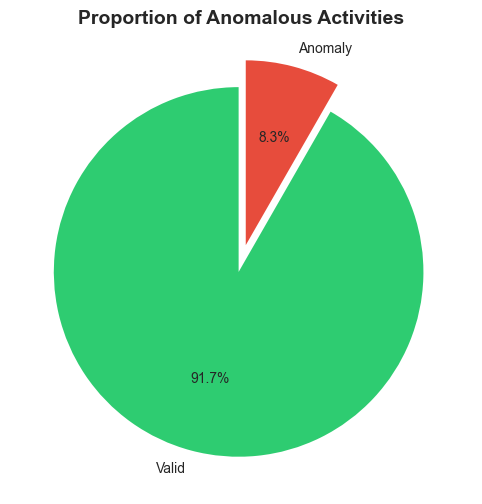


 Raw Statistics:
Valid volume: 9,171 (91.7%)
Anomaly volume: 829 (8.3%)


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
class_frequencies = graph_data['Is_Fraud'].value_counts()
hue_map = ['#2ecc71', '#e74c3c']

ax.pie(class_frequencies, labels=['Valid', 'Anomaly'], autopct='%1.1f%%', 
       colors=hue_map, startangle=90, explode=(0.05, 0.1))
ax.set_title('Proportion of Anomalous Activities', fontsize=14, fontweight='bold')
plt.show()

print(f"\n Raw Statistics:")
print(f"Valid volume: {class_frequencies[0]:,} ({class_frequencies[0]/len(graph_data)*100:.1f}%)")
print(f"Anomaly volume: {class_frequencies[1]:,} ({class_frequencies[1]/len(graph_data)*100:.1f}%)")


### 4.2 Financial Dispersion


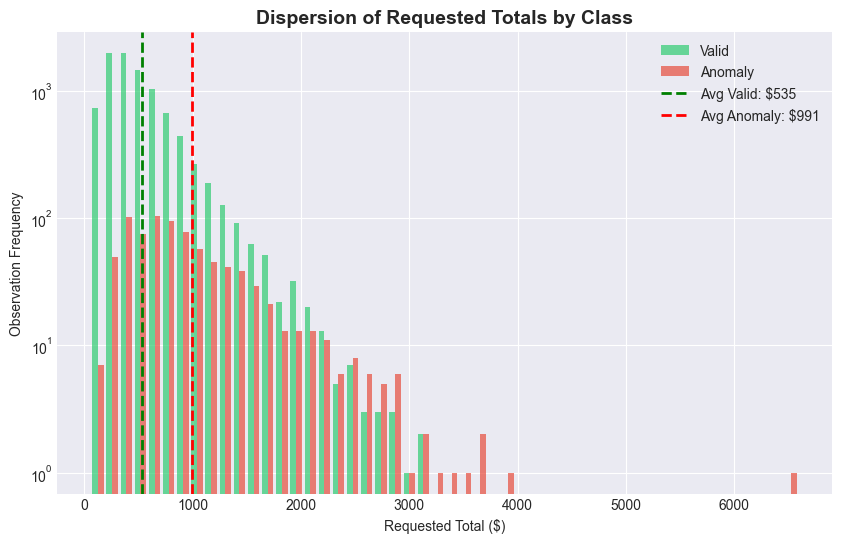

In [9]:
plt.figure(figsize=(10, 6))

valid_costs = graph_data[graph_data['Is_Fraud'] == 0]['Claim_Amount']
anomaly_costs = graph_data[graph_data['Is_Fraud'] == 1]['Claim_Amount']

plt.hist([valid_costs, anomaly_costs], bins=50, alpha=0.7, label=['Valid', 'Anomaly'], 
         color=['#2ecc71', '#e74c3c'])
plt.axvline(valid_costs.mean(), color='green', linestyle='--', linewidth=2, label=f'Avg Valid: ${valid_costs.mean():.0f}')
plt.axvline(anomaly_costs.mean(), color='red', linestyle='--', linewidth=2, label=f'Avg Anomaly: ${anomaly_costs.mean():.0f}')
plt.xlabel('Requested Total ($)')
plt.ylabel('Observation Frequency')
plt.title('Dispersion of Requested Totals by Class', fontsize=14, fontweight='bold')
plt.legend()
plt.yscale('log')
plt.show()


### 4.3 Temporal Latency


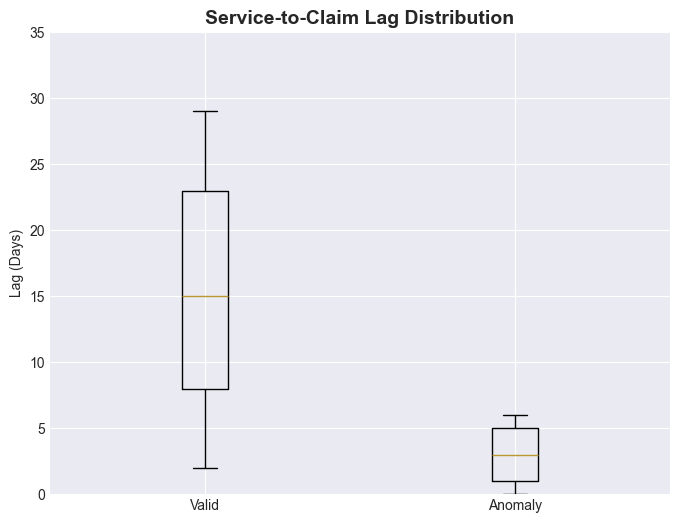

In [10]:
plt.figure(figsize=(8, 6))

delay_valid = graph_data[graph_data['Is_Fraud'] == 0]['Days_Between_Service_and_Claim']
delay_anomaly = graph_data[graph_data['Is_Fraud'] == 1]['Days_Between_Service_and_Claim']

plt.boxplot([delay_valid, delay_anomaly], labels=['Valid', 'Anomaly'])
plt.ylabel('Lag (Days)')
plt.title('Service-to-Claim Lag Distribution', fontsize=14, fontweight='bold')
plt.ylim(0, 35)
plt.show()


### 4.4 Facility Risk Index


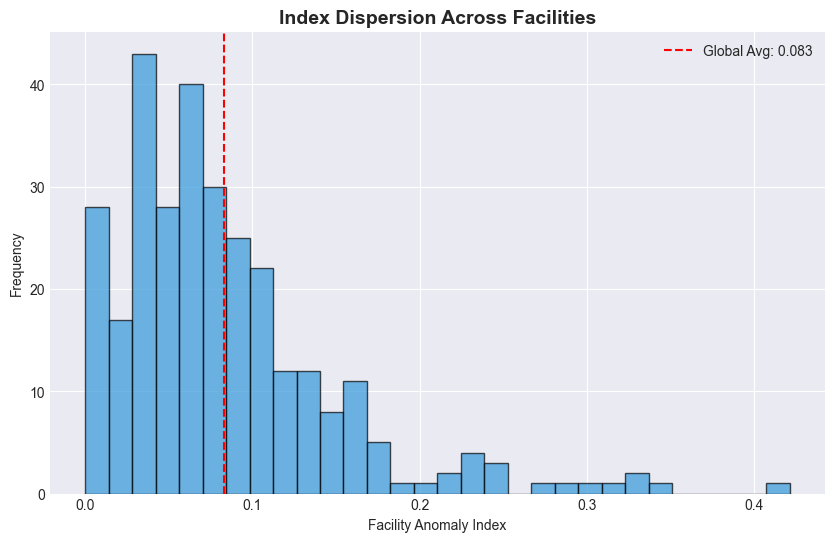

In [11]:
plt.figure(figsize=(10, 6))

facility_index = graph_data.groupby('Provider_ID')['Is_Fraud'].mean()
plt.hist(facility_index, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
plt.xlabel('Facility Anomaly Index')
plt.ylabel('Frequency')
plt.title('Index Dispersion Across Facilities', fontsize=14, fontweight='bold')
plt.axvline(facility_index.mean(), color='red', linestyle='--', label=f'Global Avg: {facility_index.mean():.3f}')
plt.legend()
plt.show()


### 4.5 Risk by Payer Segment


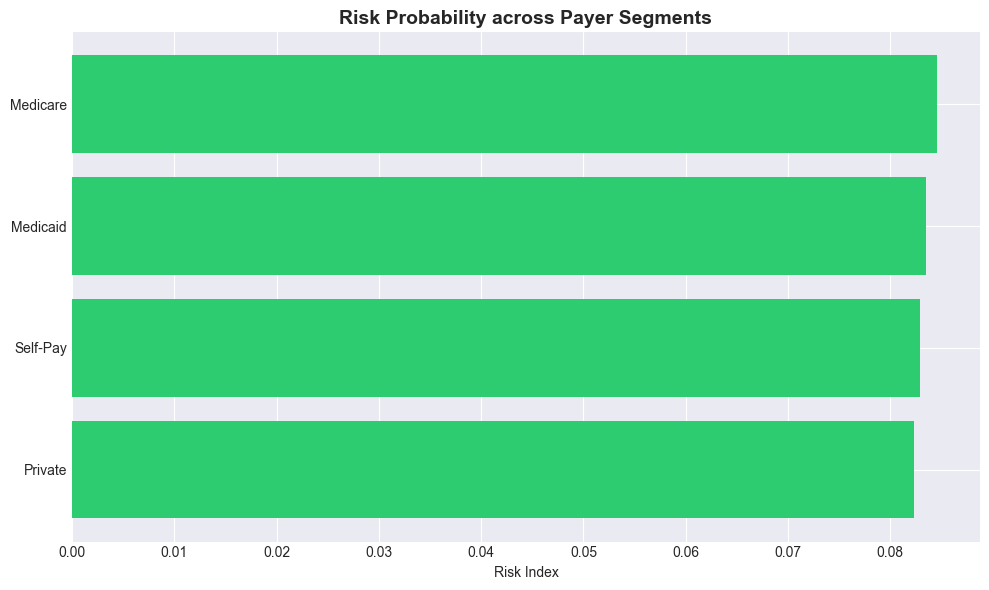

In [12]:
plt.figure(figsize=(10, 6))

payer_index = graph_data.groupby('Insurance_Type')['Is_Fraud'].mean().sort_values()
color_mapping = ['#e74c3c' if val > 0.1 else '#2ecc71' for val in payer_index.values]
plt.barh(range(len(payer_index)), payer_index.values, color=color_mapping)
plt.yticks(range(len(payer_index)), payer_index.index)
plt.xlabel('Risk Index')
plt.title('Risk Probability across Payer Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.6 Risk by Clinical Specialty


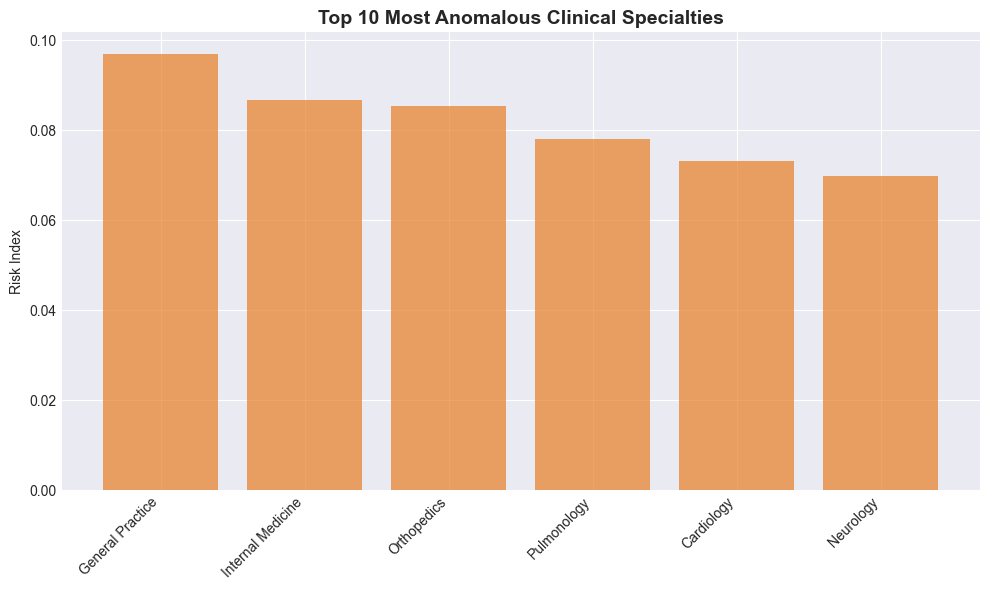

In [13]:
plt.figure(figsize=(10, 6))

specialty_idx = graph_data.groupby('Provider_Specialty')['Is_Fraud'].mean().sort_values(ascending=False).head(10)
plt.bar(range(len(specialty_idx)), specialty_idx.values, color='#e67e22', alpha=0.7)
plt.xticks(range(len(specialty_idx)), specialty_idx.index, rotation=45, ha='right')
plt.ylabel('Risk Index')
plt.title('Top 10 Most Anomalous Clinical Specialties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.7 Demographic (Age) Variation


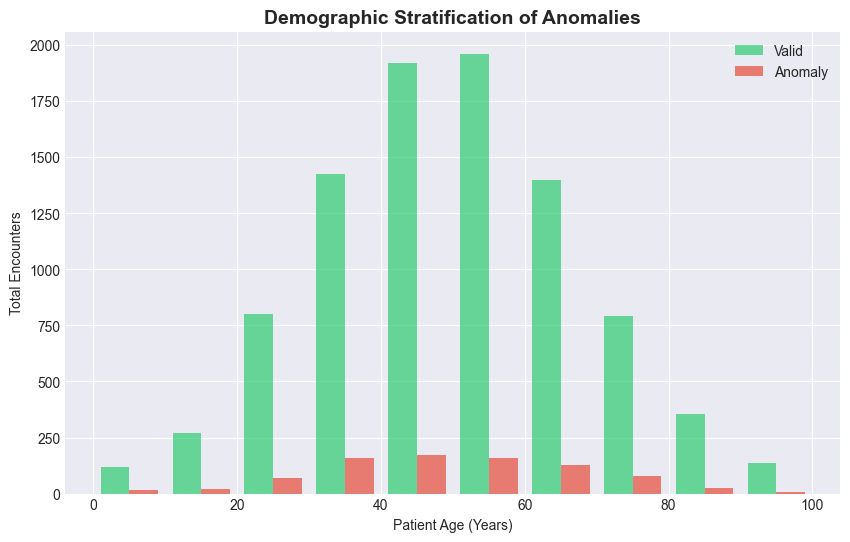

In [14]:
plt.figure(figsize=(10, 6))

age_segments = range(0, 101, 10)
valid_age = graph_data[graph_data['Is_Fraud'] == 0]['Patient_Age']
anomalous_age = graph_data[graph_data['Is_Fraud'] == 1]['Patient_Age']

plt.hist([valid_age, anomalous_age], bins=age_segments, alpha=0.7, label=['Valid', 'Anomaly'],
         color=['#2ecc71', '#e74c3c'])
plt.xlabel('Patient Age (Years)')
plt.ylabel('Total Encounters')
plt.title('Demographic Stratification of Anomalies', fontsize=14, fontweight='bold')
plt.legend()
plt.show()


### 4.8 Discrepancy Matrix: Requested vs. Allowed


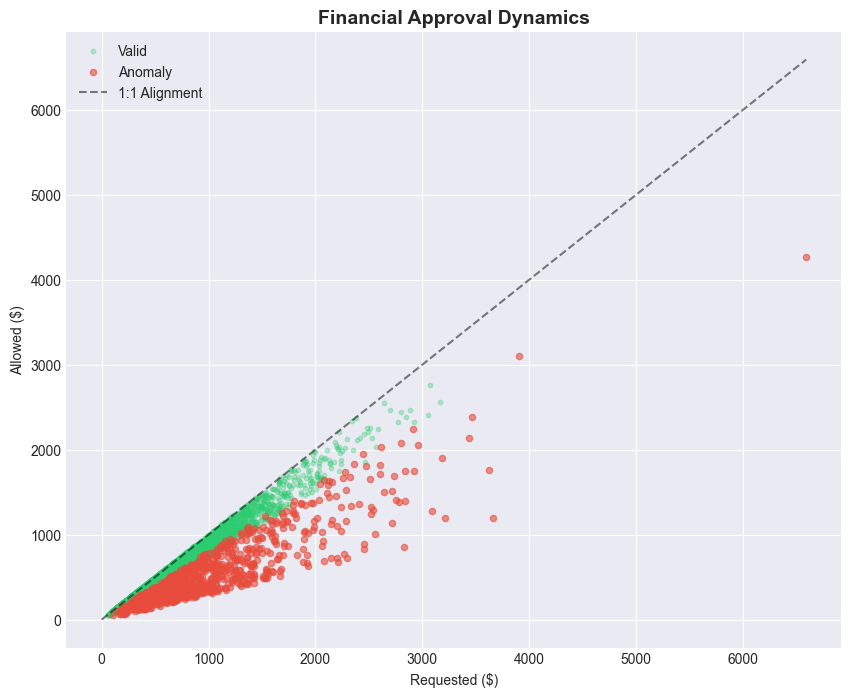

In [15]:
plt.figure(figsize=(10, 8))

plt.scatter(graph_data[graph_data['Is_Fraud'] == 0]['Claim_Amount'], 
            graph_data[graph_data['Is_Fraud'] == 0]['Approved_Amount'],
            alpha=0.3, c='#2ecc71', label='Valid', s=10)
plt.scatter(graph_data[graph_data['Is_Fraud'] == 1]['Claim_Amount'], 
            graph_data[graph_data['Is_Fraud'] == 1]['Approved_Amount'],
            alpha=0.6, c='#e74c3c', label='Anomaly', s=20)

axis_max = graph_data['Claim_Amount'].max()
plt.plot([0, axis_max], [0, axis_max], 'k--', alpha=0.5, label='1:1 Alignment')
plt.xlabel('Requested ($)')
plt.ylabel('Allowed ($)')
plt.title('Financial Approval Dynamics', fontsize=14, fontweight='bold')
plt.legend()
plt.show()


### 4.9 Latent Variable Correlations


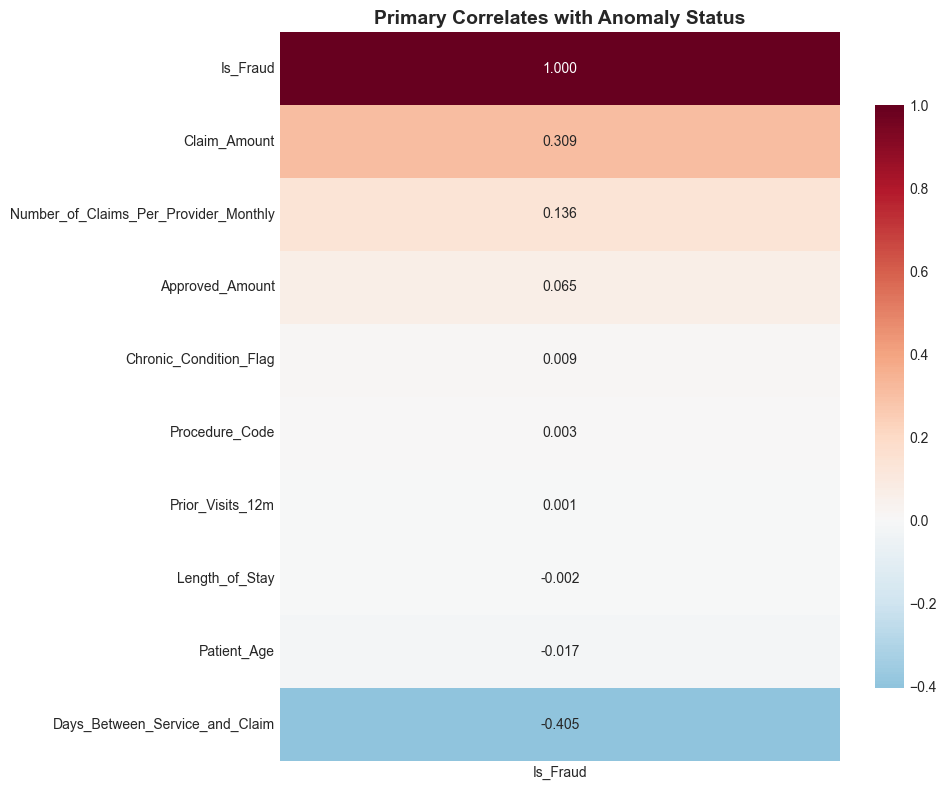

In [16]:
plt.figure(figsize=(10, 8))

quantitative_subset = graph_data.select_dtypes(include=[np.number])
pearson_r = quantitative_subset.corr()
top_alignments = pearson_r['Is_Fraud'].sort_values(ascending=False).head(15).to_frame()

sns.heatmap(top_alignments, annot=True, cmap='RdBu_r', center=0, 
            fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Primary Correlates with Anomaly Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.10 Risk by Encounter Paradigm


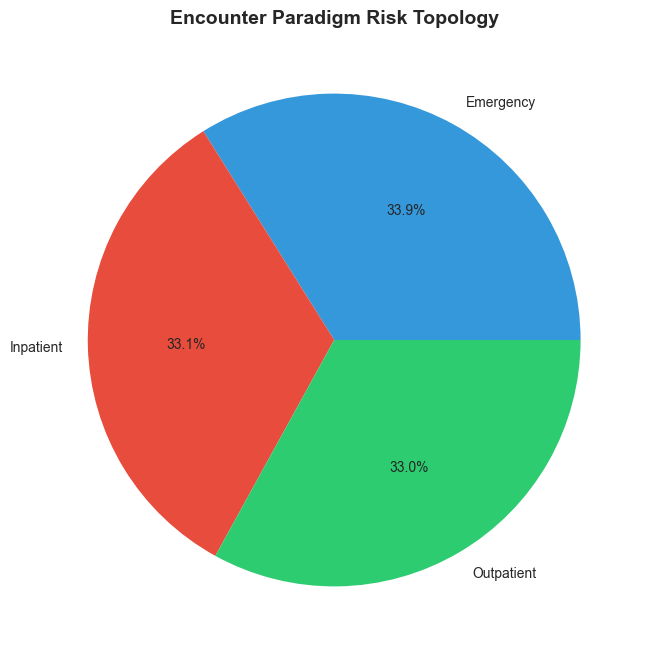

In [17]:
plt.figure(figsize=(8, 8))

encounter_idx = graph_data.groupby('Visit_Type')['Is_Fraud'].mean()
plt.pie(encounter_idx.values, labels=encounter_idx.index, autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Encounter Paradigm Risk Topology', fontsize=14, fontweight='bold')
plt.show()


### 4.11 Disposition Status Risk


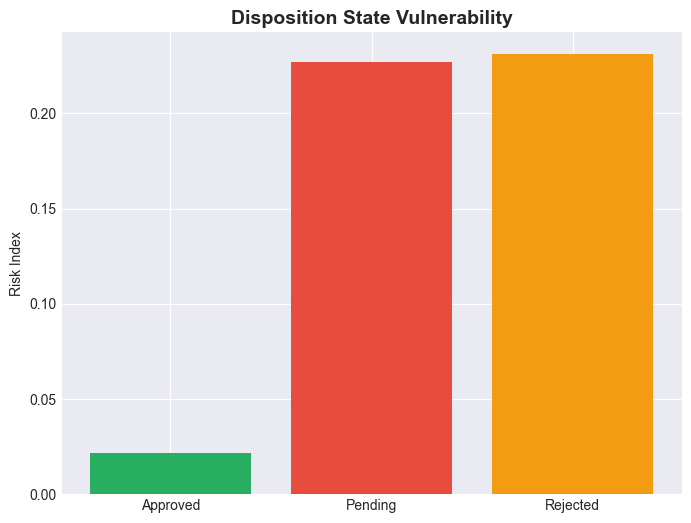

In [18]:
plt.figure(figsize=(8, 6))

dispo_idx = graph_data.groupby('Claim_Status')['Is_Fraud'].mean()
plt.bar(range(len(dispo_idx)), dispo_idx.values, color=['#27ae60', '#e74c3c', '#f39c12'])
plt.xticks(range(len(dispo_idx)), dispo_idx.index)
plt.ylabel('Risk Index')
plt.title('Disposition State Vulnerability', fontsize=14, fontweight='bold')
plt.show()


### 4.12 Longitudinal Patient History


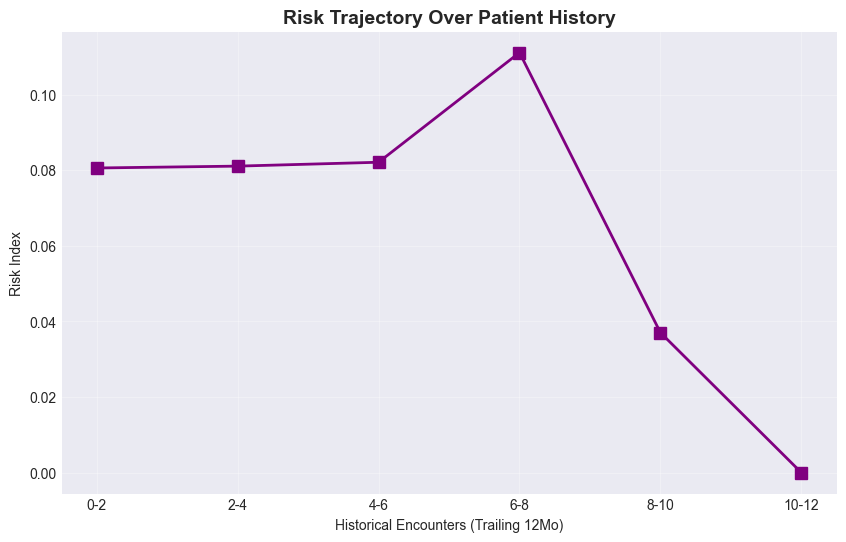

In [19]:
plt.figure(figsize=(10, 6))

history_intervals = range(0, 13, 2)
graph_data['History_Stratum'] = pd.cut(graph_data['Prior_Visits_12m'], bins=history_intervals)
history_idx = graph_data.groupby('History_Stratum')['Is_Fraud'].mean()

plt.plot(range(len(history_idx)), history_idx.values, marker='s', linewidth=2, markersize=8, color='purple')
plt.xticks(range(len(history_idx)), [f'{j}-{j+2}' for j in range(0, 12, 2)])
plt.xlabel('Historical Encounters (Trailing 12Mo)')
plt.ylabel('Risk Index')
plt.title('Risk Trajectory Over Patient History', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()


# 5. Modeling Pipeline and Architecture
Defining the predictive engine and preparing the vectors to prevent target leakage.


In [20]:
def construct_modeling_pipeline(base_frame):
    
    # Prune non-predictive or redundant keys
    drop_targets = ['Claim_ID', 'Provider_ID', 'Diagnosis_Code', 'Procedure_Code',
                    'Claim_Submission_Date', 'Is_Fraud', 'History_Stratum', 'Age_Bracket']
    
    predictor_keys = [
        k for k in base_frame.columns 
        if k not in drop_targets and base_frame[k].dtype in ['int64', 'float64', 'bool', 'int32']
    ]
    
    predictors = base_frame[predictor_keys].copy()
    target = base_frame['Is_Fraud'].copy()
    
    print(f"\nTotal inputs fed into the algorithm: {len(predictor_keys)}")
    
    # Sequential stratifications to isolate validation and holdout sets
    P_train_temp, P_holdout, t_train_temp, t_holdout = train_test_split(
        predictors, target, test_size=0.2, random_state=101, stratify=target
    )
    
    P_train, P_val, t_train, t_val = train_test_split(
        P_train_temp, t_train_temp, test_size=0.25, random_state=101, stratify=t_train_temp
    )
    
    # Null resolution strategies
    median_filler = SimpleImputer(strategy='median')
    P_train_filled = pd.DataFrame(median_filler.fit_transform(P_train), columns=P_train.columns)
    P_val_filled = pd.DataFrame(median_filler.transform(P_val), columns=P_val.columns)
    P_holdout_filled = pd.DataFrame(median_filler.transform(P_holdout), columns=P_holdout.columns)
    
    # Bound anomalies (Infinities)
    P_train_filled = P_train_filled.replace([np.inf, -np.inf], np.nan).fillna(P_train_filled.median())
    P_val_filled = P_val_filled.replace([np.inf, -np.inf], np.nan).fillna(P_train_filled.median())
    P_holdout_filled = P_holdout_filled.replace([np.inf, -np.inf], np.nan).fillna(P_train_filled.median())
    
    # Variance stabilization
    z_scaler = StandardScaler()
    P_train_norm = pd.DataFrame(z_scaler.fit_transform(P_train_filled), columns=P_train.columns)
    P_val_norm = pd.DataFrame(z_scaler.transform(P_val_filled), columns=P_val.columns)
    P_holdout_norm = pd.DataFrame(z_scaler.transform(P_holdout_filled), columns=P_holdout.columns)
    
    # Synthetic class augmentation
    smote_engine = SMOTE(random_state=101)
    P_train_smote, t_train_smote = smote_engine.fit_resample(P_train_norm, t_train)
    
    pipeline_artifacts = {
        'Train_X': P_train_smote, 'Val_X': P_val_norm, 'Holdout_X': P_holdout_norm,
        'Train_Y': t_train_smote, 'Val_Y': t_val, 'Holdout_Y': t_holdout,
        'Keys': predictor_keys, 'Scaler': z_scaler, 'Filler': median_filler
    }
    
    return pipeline_artifacts

pipeline_artifacts = construct_modeling_pipeline(processed_records)



Total inputs fed into the algorithm: 43


# 6. Classifier Execution
Executing ensemble tree estimators (Random Forest and Gradient Boosted Trees) and verifying metrics.


--- INITIATING RANDOM FOREST ESTIMATOR ---

Validation Output (Random Forest):
Area Under Curve: 0.9987
              precision    recall  f1-score   support

       Valid       0.99      1.00      1.00      1834
     Anomaly       0.97      0.94      0.95       166

    accuracy                           0.99      2000
   macro avg       0.98      0.97      0.98      2000
weighted avg       0.99      0.99      0.99      2000

--- INITIATING XGBOOST ESTIMATOR ---

Validation Output (XGBoost):
Area Under Curve: 0.9986
              precision    recall  f1-score   support

       Valid       0.99      1.00      1.00      1834
     Anomaly       0.97      0.93      0.95       166

    accuracy                           0.99      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.99      0.99      0.99      2000


      HOLDOUT TEST SET METRICS      

>>> Random Forest Performance:
AUC: 0.9994

>>> XGBoost Performance:
AUC: 0.9990

--- TREE STRUCTURE IMPORTANCE

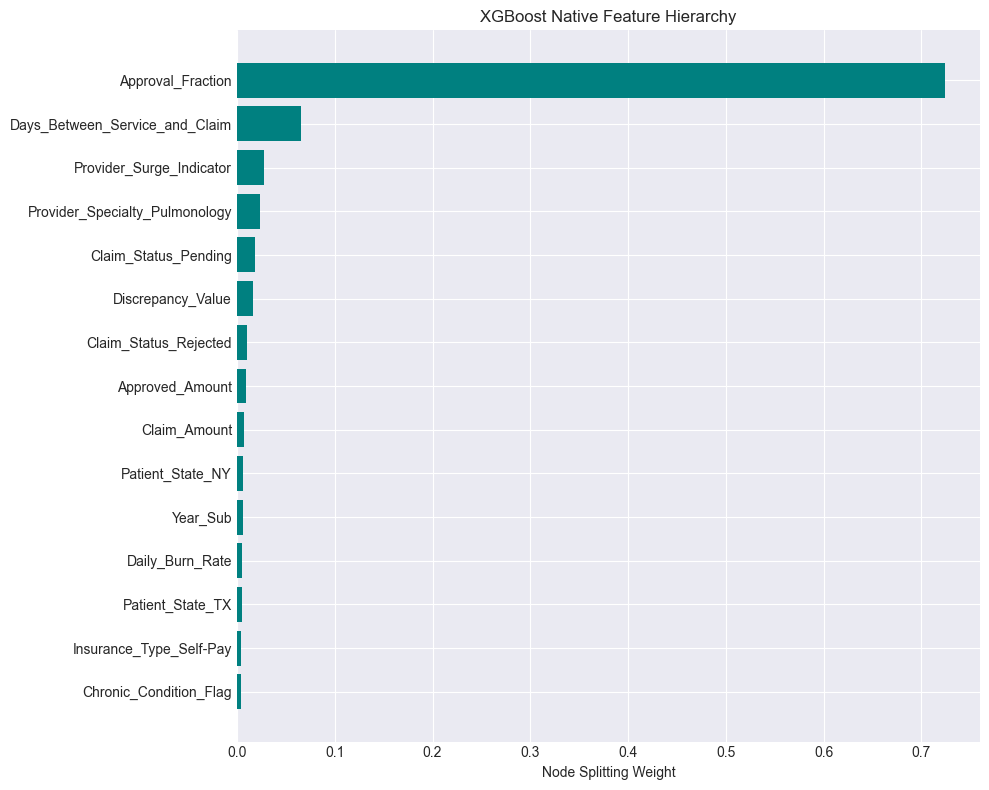

In [21]:
def build_and_assess_classifiers(artifacts):
    
    X_T = artifacts['Train_X']
    X_V = artifacts['Val_X']
    X_H = artifacts['Holdout_X']
    Y_T = artifacts['Train_Y']
    Y_V = artifacts['Val_Y']
    Y_H = artifacts['Holdout_Y']
    
    imbalance_ratio = len(Y_T[Y_T==0]) / len(Y_T[Y_T==1])
    
    print("--- INITIATING RANDOM FOREST ESTIMATOR ---")
    
    rf_estimator = RandomForestClassifier(
        n_estimators=120,
        max_depth=12,
        class_weight='balanced',
        random_state=101,
        n_jobs=-1
    )
    rf_estimator.fit(X_T, Y_T)
    
    rf_probs_v = rf_estimator.predict_proba(X_V)[:, 1]
    rf_preds_v = rf_estimator.predict(X_V)
    rf_probs_h = rf_estimator.predict_proba(X_H)[:, 1]
    rf_preds_h = rf_estimator.predict(X_H)
    
    print("\nValidation Output (Random Forest):")
    print(f"Area Under Curve: {roc_auc_score(Y_V, rf_probs_v):.4f}")
    print(classification_report(Y_V, rf_preds_v, target_names=['Valid', 'Anomaly']))
    
    print("--- INITIATING XGBOOST ESTIMATOR ---")
    
    xgb_estimator = XGBClassifier(
        n_estimators=350,
        max_depth=7,
        learning_rate=0.03,
        scale_pos_weight=imbalance_ratio,
        random_state=101,
        eval_metric='auc',
    )
    
    xgb_estimator.fit(
        X_T, Y_T,
        eval_set=[(X_V, Y_V)],
        verbose=False
    )
    
    xgb_probs_v = xgb_estimator.predict_proba(X_V)[:, 1]
    xgb_preds_v = xgb_estimator.predict(X_V)
    xgb_probs_h = xgb_estimator.predict_proba(X_H)[:, 1]
    xgb_preds_h = xgb_estimator.predict(X_H)
    
    print("\nValidation Output (XGBoost):")
    print(f"Area Under Curve: {roc_auc_score(Y_V, xgb_probs_v):.4f}")
    print(classification_report(Y_V, xgb_preds_v, target_names=['Valid', 'Anomaly']))
    
    print("\n====================================")
    print("      HOLDOUT TEST SET METRICS      ")
    print("====================================")
    
    print("\n>>> Random Forest Performance:")
    print(f"AUC: {roc_auc_score(Y_H, rf_probs_h):.4f}")
    
    print("\n>>> XGBoost Performance:")
    print(f"AUC: {roc_auc_score(Y_H, xgb_probs_h):.4f}")
    
    print("\n--- TREE STRUCTURE IMPORTANCE ---")
    
    tree_weights = pd.DataFrame({
        'Attribute': artifacts['Keys'],
        'Weight': xgb_estimator.feature_importances_
    }).sort_values('Weight', ascending=False).head(15)
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(tree_weights)), tree_weights['Weight'].values, color='teal')
    plt.yticks(range(len(tree_weights)), tree_weights['Attribute'].values)
    plt.xlabel('Node Splitting Weight')
    plt.title('XGBoost Native Feature Hierarchy')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return xgb_estimator, rf_estimator

fitted_models = build_and_assess_classifiers(pipeline_artifacts)


In [22]:
# SHAP instantiation using the XGBoost artifact
primary_model = fitted_models[0]
shap_engine = shap.TreeExplainer(primary_model)


In [23]:
def interpret_prediction(idx, estimator, explainer, artifacts):
    
    vector_space = artifacts['Holdout_X']
    target_vector = vector_space.iloc[idx:idx+1]
    
    # Calculate anomaly certainty
    certainty = estimator.predict_proba(target_vector)[0][1]
    
    # Extract marginal contributions
    marginals = explainer.shap_values(target_vector)[0]
    
    # Construct interpretation schema
    interpret_df = pd.DataFrame({
        "Attribute": vector_space.columns,
        "Actual_Input": target_vector.values[0],
        "Contribution": marginals
    })
    
    interpret_df["Magnitude"] = np.abs(interpret_df["Contribution"])
    interpret_df = interpret_df.sort_values("Magnitude", ascending=False)
    
    # Isolate directional pushes
    positive_push = interpret_df[interpret_df["Contribution"] > 0].head(5)
    negative_push = interpret_df[interpret_df["Contribution"] < 0].head(5)
    
    # Map certainty to discrete bands using a dictionary map instead of if-elif chain
    def get_band(c):
        if c >= 0.8: return "CRITICAL"
        if c >= 0.6: return "ELEVATED"
        if c >= 0.4: return "MODERATE"
        return "NEGLIGIBLE"
        
    band = get_band(certainty)
    
    print(f"=== ENCOUNTER REF ID: {idx} ===")
    print(f" Anomaly Confidence: {certainty:.4f}")
    print(f" Escalation Band: {band}")
    
    print("\n [PRO-ANOMALY DRIVERS]:")
    print(positive_push[["Attribute", "Actual_Input", "Contribution"]])
    
    print("\n [ANTI-ANOMALY DRIVERS]:")
    print(negative_push[["Attribute", "Actual_Input", "Contribution"]])
    
    return {
        "confidence": certainty,
        "band": band,
        "details": interpret_df
    }


In [24]:
evaluation_outcome = interpret_prediction(
    idx=10,
    estimator=fitted_models[0],
    explainer=shap_engine,
    artifacts=pipeline_artifacts
)


=== ENCOUNTER REF ID: 10 ===
 Anomaly Confidence: 0.0001
 Escalation Band: NEGLIGIBLE

 [PRO-ANOMALY DRIVERS]:
                              Attribute  Actual_Input  Contribution
27  Provider_Specialty_General Practice      2.101229      0.060621
41                 Visit_Type_Inpatient      1.443895      0.029986
2                       Approved_Amount     -0.760062      0.023251
5                        Length_of_Stay     -0.122770      0.018310
12                           Is_Weekend      1.554624      0.008278

 [ANTI-ANOMALY DRIVERS]:
                         Attribute  Actual_Input  Contribution
13               Approval_Fraction     -0.572699     -5.426612
3   Days_Between_Service_and_Claim      0.183407     -2.648562
15               Discrepancy_Value     -0.561494     -0.488792
39            Claim_Status_Pending     -0.362540     -0.293185
40           Claim_Status_Rejected     -0.455773     -0.114435
